# BÁO CÁO CHIẾN LƯỢC PHÁT TRIỂN ỨNG DỤNG GOOGLE PLAY STORE
**Phạm vi dữ liệu:** Phân tích thực tế trên **8,892 ứng dụng Android** hoạt động trong giai đoạn từ **tháng 05/2010 đến tháng 08/2018**.
**Mục tiêu báo cáo:** Cung cấp bức tranh toàn cảnh thị trường, mô hình kinh doanh hiệu quả và đề xuất định hướng đầu tư sản phẩm cho Ban Giám đốc.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cấu hình hiển thị trực quan cho báo cáo CEO
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = 'none'

# Đọc dữ liệu đã làm sạch
df = pd.read_csv('googleplaystore_cleaned.csv')
df['Last_Updated_Date'] = pd.to_datetime(df['Last_Updated_Date'])

# Tính toán các chỉ số kinh doanh cốt lõi
total_apps = len(df)
avg_rating = df['Rating'].mean()
pct_free = (df['Type'] == 'Free').mean() * 100
pct_paid = 100 - pct_free
top_cat = df['Category'].value_counts().index[0]
top_cat_count = df['Category'].value_counts().iloc[0]
top_cat_pct = (top_cat_count / total_apps) * 100

print('========================================================================================')
print('                         CHỈ SỐ THỊ TRƯỜNG TRỌNG YẾU (EXECUTIVE SUMMARY)')
print('========================================================================================')
print(f'  1. TỔNG SỐ ỨNG DỤNG PHÂN TÍCH   :  {total_apps:,} ứng dụng')
print(f'  2. ĐIỂM ĐÁNH GIÁ TRUNG BÌNH     :  {avg_rating:.2f} / 5.0 sao')
print(f'  3. MÔ HÌNH PHÁT HÀNH            :  Miễn phí {pct_free:.1f}%  |  Trả phí {pct_paid:.1f}%')
print(f'  4. DANH MỤC CÓ SỐ LƯỢNG LỚN NHẤT:  {top_cat} ({top_cat_count:,} ứng dụng, chiếm {top_cat_pct:.1f}% tổng số)')
print('========================================================================================')

                         CHỈ SỐ THỊ TRƯỜNG TRỌNG YẾU (EXECUTIVE SUMMARY)
  1. TỔNG SỐ ỨNG DỤNG PHÂN TÍCH   :  8,892 ứng dụng
  2. ĐIỂM ĐÁNH GIÁ TRUNG BÌNH     :  4.19 / 5.0 sao
  3. MÔ HÌNH PHÁT HÀNH            :  Miễn phí 93.1%  |  Trả phí 6.9%
  4. DANH MỤC CÓ SỐ LƯỢNG LỚN NHẤT:  FAMILY (1,718 ứng dụng, chiếm 19.3% tổng số)


## Game và Truyền thông là hai danh mục thu hút lượt tải lớn nhất thị trường

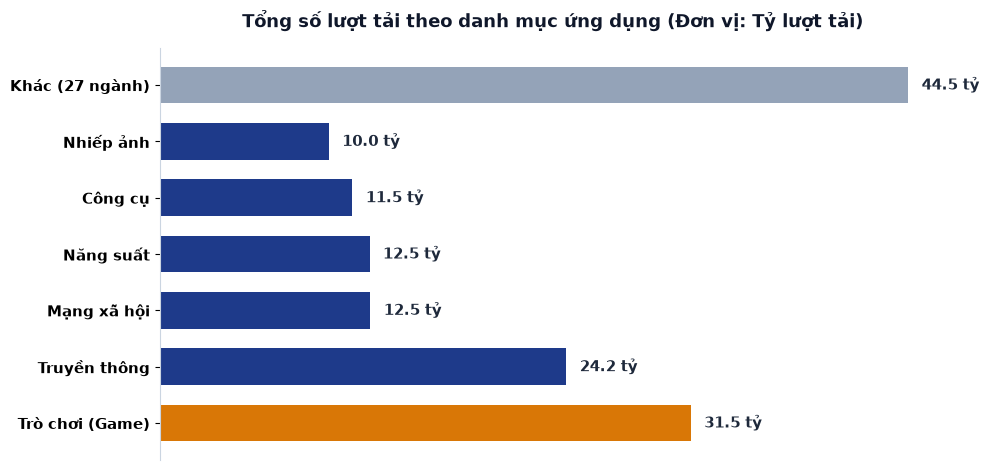

In [2]:
def plot_category_investment(df):
    """Vẽ biểu đồ các danh mục ứng dụng thu hút lượt tải cao nhất."""
    # Nhóm dữ liệu theo Category và tính tổng lượt tải (tỷ lượt)
    cat_installs = df.groupby('Category')['Installs_Num'].sum().sort_values(ascending=False)
    
    # Lấy Top 6 danh mục hàng đầu và gộp phần còn lại vào 'Khác'
    top6 = cat_installs.head(6)
    other_val = cat_installs.iloc[6:].sum()
    plot_data = pd.concat([top6, pd.Series({'Khác': other_val})]) / 1e9
    
    # Tên danh mục thân thiện bằng tiếng Việt
    cat_labels = [
        'Trò chơi (Game)',
        'Truyền thông',
        'Mạng xã hội',
        'Năng suất',
        'Công cụ',
        'Nhiếp ảnh',
        'Khác (27 ngành)'
    ]
    
    # Bảng màu: Sleek Navy Blue chủ đạo + Orange Highlight cho vị trí dẫn đầu (Game)
    colors = ['#D97706', '#1E3A8A', '#1E3A8A', '#1E3A8A', '#1E3A8A', '#1E3A8A', '#94A3B8']
    
    fig, ax = plt.subplots(figsize=(10, 4.8))
    
    # Vẽ bar chart ngang để trình bày rõ ràng
    y_pos = np.arange(len(plot_data))
    bars = ax.barh(y_pos, plot_data.values[::-1], color=colors[::-1], height=0.65)
    
    # Thiết lập nhãn trục y
    ax.set_yticks(y_pos)
    ax.set_yticklabels(cat_labels[::-1], fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    
    # Thêm con số trực tiếp lên đầu mỗi cột
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.8, bar.get_y() + bar.get_height()/2, f'{width:.1f} tỷ', 
                ha='left', va='center', fontsize=11, fontweight='bold', color='#1E293B')
    
    # Tối giản đồ họa: loại bỏ gridlines và khung viền thừa
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_color('#CBD5E1')
    
    plt.title('Tổng số lượt tải theo danh mục ứng dụng (Đơn vị: Tỷ lượt tải)', 
              fontsize=13, fontweight='bold', pad=15, color='#0F172A')
    plt.tight_layout()
    plt.show()

plot_category_investment(df)

Nhận xét: Mặc dù danh mục Gia đình (Family) sở hữu số lượng ứng dụng nhiều nhất, nhưng Trò chơi (Game) và Truyền thông (Communication) mới là hai mảng thu hút nhu cầu người dùng lớn nhất với tổng lượt tải vượt 55 tỷ lượt. Đây là những danh mục mang lại tiềm năng quy mô người dùng lớn nhất cho doanh nghiệp khi đầu tư.

## Ứng dụng miễn phí có lượng tải trung bình cao gấp 150 lần ứng dụng trả phí

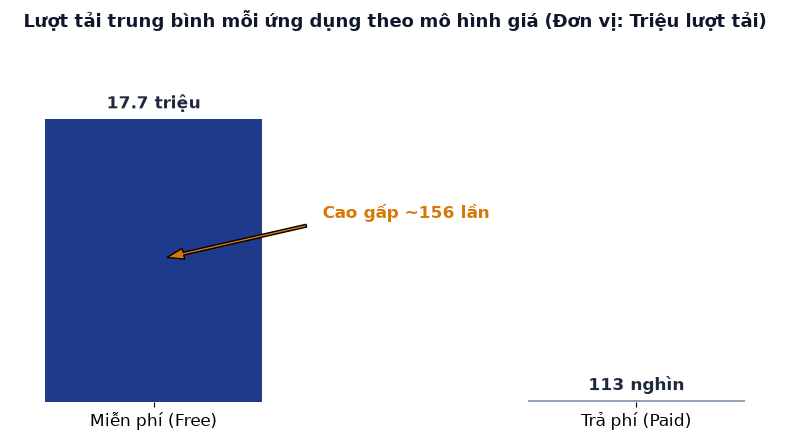

In [3]:
def plot_pricing_strategy(df):
    """Vẽ biểu đồ so sánh lượng tải trung bình giữa ứng dụng Miễn phí và Trả phí."""
    # Tính lượng tải trung bình (triệu lượt) theo từng mô hình giá
    price_stats = df.groupby('Type')['Installs_Num'].mean() / 1e6
    categories = ['Miễn phí (Free)', 'Trả phí (Paid)']
    values = [price_stats.get('Free', 0), price_stats.get('Paid', 0)]
    
    # Bảng màu: Highlight cột Miễn phí
    colors = ['#1E3A8A', '#94A3B8']
    
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(categories, values, color=colors, width=0.45)
    
    # Hiển thị số liệu trực tiếp trên đầu cột
    for bar in bars:
        height = bar.get_height()
        text_val = f'{height:.1f} triệu' if height >= 1 else f'{height*1000:.0f} nghìn'
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.4, text_val, 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='#1E293B')
    
    # Thêm ghi chú mức chênh lệch
    ax.annotate('Cao gấp ~156 lần',
                xy=(0, values[0]/2), xytext=(0.35, values[0]*0.65),
                arrowprops=dict(facecolor='#D97706', shrink=0.08, width=2, headwidth=8),
                fontsize=12, fontweight='bold', color='#D97706')
    
    # Loại bỏ trục y, grid lines và khung viền thừa
    ax.set_yticks([])
    ax.set_ylim(0, values[0] * 1.25)
    ax.tick_params(axis='x', labelsize=12)
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    plt.title('Lượt tải trung bình mỗi ứng dụng theo mô hình giá (Đơn vị: Triệu lượt tải)', 
              fontsize=13, fontweight='bold', pad=15, color='#0F172A')
    plt.tight_layout()
    plt.show()

plot_pricing_strategy(df)

Nhận xét: Mô hình miễn phí tải về là yếu tố bắt buộc để thu hút quy mô người dùng lớn với lượng tải trung bình đạt 17.7 triệu lượt/app (so với 113 nghìn lượt/app ở nhóm trả phí). Doanh nghiệp nên ưu tiên chiến lược phát hành miễn phí kết hợp tạo doanh thu qua quảng cáo hoặc bán gói tính năng bổ sung (In-App Purchases).

## Thị trường bùng nổ mạnh mẽ với làn sóng cập nhật ứng dụng từ năm 2017 đến 2018

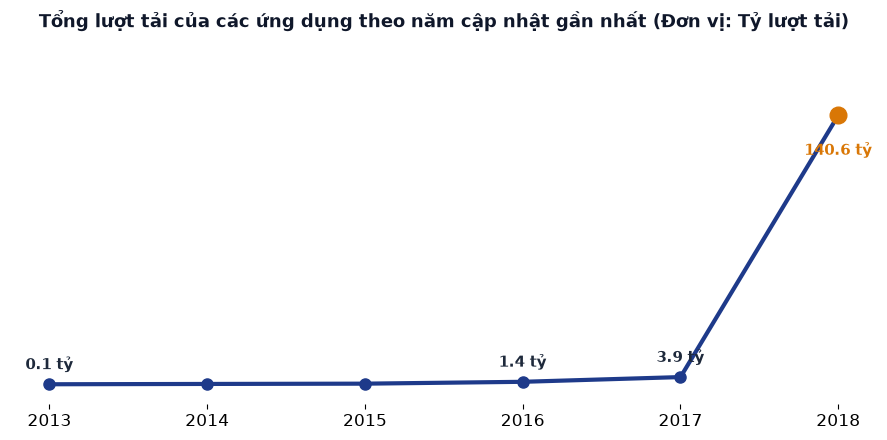

In [4]:
def plot_market_trend(df):
    """Vẽ biểu đồ đường thể hiện xu hướng tăng trưởng lượt tải theo năm cập nhật."""
    df_trend = df.copy()
    df_trend['Year'] = df_trend['Last_Updated_Date'].dt.year
    
    # Lấy dữ liệu từ 2013 đến 2018
    yearly_installs = df_trend[df_trend['Year'] >= 2013].groupby('Year')['Installs_Num'].sum() / 1e9
    
    fig, ax = plt.subplots(figsize=(9, 4.5))
    years = [str(y) for y in yearly_installs.index]
    values = yearly_installs.values
    
    # Vẽ đường xu hướng tối giản
    ax.plot(years, values, marker='o', linewidth=3, markersize=8, color='#1E3A8A')
    
    # Highlight điểm bùng nổ năm 2018
    ax.plot(years[-1], values[-1], marker='o', markersize=12, color='#D97706')
    
    # Ghi nhãn giá trị trực tiếp tại các điểm mốc
    for i, (yr, val) in enumerate(zip(years, values)):
        if yr in ['2013', '2016', '2017', '2018']:
            offset = 6 if yr != '2018' else -14
            va_align = 'bottom' if yr != '2018' else 'top'
            ax.text(i, val + offset, f'{val:.1f} tỷ', ha='center', va=va_align, 
                    fontsize=11, fontweight='bold', color='#D97706' if yr == '2018' else '#1E293B')
    
    # Tối giản đồ họa: loại bỏ grid, trục y và khung viền
    ax.set_yticks([])
    ax.set_ylim(-10, max(values) * 1.25)
    ax.tick_params(axis='x', labelsize=12)
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    plt.title('Tổng lượt tải của các ứng dụng theo năm cập nhật gần nhất (Đơn vị: Tỷ lượt tải)', 
              fontsize=13, fontweight='bold', pad=15, color='#0F172A')
    plt.tight_layout()
    plt.show()

plot_market_trend(df)

Nhận xét: Các ứng dụng được duy trì và cập nhật trong giai đoạn 2017 - 2018 chiếm áp đảo về lượng tải thực tế trên thị trường (đạt đỉnh 140.6 tỷ lượt tải năm 2018). Điều này cho thấy việc duy trì tần suất cập nhật định kỳ là điều kiện tiên quyết để giữ chân người dùng và duy trì sức hút sản phẩm.

## ĐỀ XUẤT HÀNH ĐỘNG CHO BAN GIÁM ĐỐC
* **Tập trung nguồn lực vào danh mục có quy mô lớn:** Ưu tiên nguồn lực đầu tư phát triển các sản phẩm thuộc nhóm **Trò chơi (Game)** hoặc **Truyền thông & Mạng xã hội** để tiếp cận tệp người dùng rộng lớn nhất.
* **Áp dụng mô hình Freemium (Tải miễn phí, thu phí trong ứng dụng):** Loại bỏ rào cản tài chính bằng cách phát hành miễn phí, sau đó tạo doanh thu bền vững từ quảng cáo hoặc bán gói tính năng nâng cao (In-App Purchases).
* **Duy trì chu kỳ cập nhật sản phẩm liên tục:** Xây dựng quy trình cải tiến tính năng và cập nhật ứng dụng định kỳ nhằm tối ưu hóa tương tác, đón đầu làn sóng tăng trưởng của thị trường di động.